# Mount Google Drive

In [9]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Library

In [3]:
# Import semua library
import cv2
import numpy as np
import pandas as pd
import os
import random
import shutil
import zipfile
from tqdm import tqdm
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label
from skimage.filters import threshold_otsu
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skimage.measure import regionprops, label as skimage_label
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Tentukan Path Dataset

In [11]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/oxford17'

# Seed untuk reproducibility
random.seed(42)

# Cek folder
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Folder tidak ditemukan: {dataset_path}. Periksa kembali path Anda.")

# Daftar semua file gambar
all_images = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
total_images = len(all_images)
selected_images = all_images
print(f"Total gambar di dataset: {total_images}")

Total gambar di dataset: 239


# Ekstraksi Fitur

## Definisi kelas dan fungsi ekstraksi fitur

In [12]:
classes = [
    "daffodil", "snowdrop", "lilyvalley", "bluebell", "crocus", "iris", "tigerlily", "tulip",
    "fritillary", "sunflower", "daisy", "coltsfoot", "dandelion", "cowslip", "buttercup",
    "windflower", "pansy"
]

# Fungsi ekstraksi fitur
def extract_color_moments(image):
    moments = []
    for channel in cv2.split(image):
        moments.append(np.mean(channel))
        moments.append(np.std(channel))
        moments.append(np.mean(np.abs(channel - np.mean(channel))**3)**(1./3))
    return moments

## Fungsi ekstraksi fitur tekstur (GLCM)

In [13]:
def extract_glcm_features(gray):
    glcm = graycomatrix(gray, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], 256, symmetric=True)
    return [
        graycoprops(glcm, 'contrast').mean(),
        graycoprops(glcm, 'dissimilarity').mean(),
        graycoprops(glcm, 'homogeneity').mean(),
        graycoprops(glcm, 'energy').mean(),
        graycoprops(glcm, 'correlation').mean()
    ]

## Fungsi ekstraksi fitur bentuk (area & perimeter)

In [14]:
def extract_shape_features(gray):
    thresh = threshold_otsu(gray)
    binary = gray > thresh
    labeled_img = skimage_label(binary)
    regions = regionprops(labeled_img)
    if not regions:
        return [0, 0]
    largest = max(regions, key=lambda r: r.area)
    return [largest.area, largest.perimeter]

## Loop ekstraksi fitur untuk semua gambar

In [16]:
features = []
for img_name in tqdm(selected_images, desc="Ekstraksi fitur"):
    img_path = os.path.join(dataset_path, img_name)
    image = cv2.imread(img_path)
    if image is None:
        continue

    try:
        idx = int(img_name.split('_')[1].split('.')[0])
        class_idx = (idx - 1) // 80
        flower_class = classes[class_idx]
    except:
        flower_class = "unknown"

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    color_feat = extract_color_moments(image_rgb)
    texture_feat = extract_glcm_features(gray)
    shape_feat = extract_shape_features(gray)

    all_feat = color_feat + texture_feat + shape_feat + [flower_class, img_name]
    features.append(all_feat)

Ekstraksi fitur: 100%|██████████| 239/239 [00:29<00:00,  8.08it/s]


## Simpan hasil ekstraksi ke file CSV

In [17]:
# DataFrame
columns = ['R_mean','R_std','R_skew','G_mean','G_std','G_skew',
           'B_mean','B_std','B_skew','contrast','dissimilarity',
           'homogeneity','energy','correlation','area','perimeter','class','filename']
df = pd.DataFrame(features, columns=columns)

# Simpan CSV
# Tentukan folder tujuan di Google Drive
save_folder = '/content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi'

# Buat folder jika belum ada (termasuk folder induk)
os.makedirs(save_folder, exist_ok=True)

# Nama file CSV
csv_filename = f'flower_features_{len(df)}samples.csv'

# Path lengkap
csv_path = os.path.join(save_folder, csv_filename)

# Simpan CSV
df.to_csv(csv_path, index=False)

print(f" File CSV berhasil disimpan ke: {csv_path}")
print(f"\n Ekstraksi selesai. Total {len(df)} sampel. Disimpan ke {csv_filename}")

 File CSV berhasil disimpan ke: /content/drive/MyDrive/Colab Notebooks/hasil_ekstraksi/flower_features_239samples.csv

 Ekstraksi selesai. Total 239 sampel. Disimpan ke flower_features_239samples.csv


# Pembersihan data, training Random Forest dan Evaluasi model (akurasi & classification report)

In [18]:
# Bersihkan data (hapus 'unknown' jika ada)
df = df[df['class'] != 'unknown']
X = df.drop(['class','filename'], axis=1)
y = df['class']

print(f"Jumlah sampel setelah cleaning: {len(X)}")
print(f"Jumlah fitur: {X.shape[1]}")
print(f"Kelas unik: {y.nunique()}")

# Split data (80% train, 20% test) dengan stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prediksi & evaluasi
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi pada test set: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))



Jumlah sampel setelah cleaning: 239
Jumlah fitur: 16
Kelas unik: 3

🎯 Akurasi pada test set: 0.7708 (77.08%)

📋 Classification Report:
              precision    recall  f1-score   support

   tigerlily       0.83      0.62      0.71        16
       tulip       0.72      0.81      0.76        16
  windflower       0.78      0.88      0.82        16

    accuracy                           0.77        48
   macro avg       0.78      0.77      0.77        48
weighted avg       0.78      0.77      0.77        48



# Confusion matrix

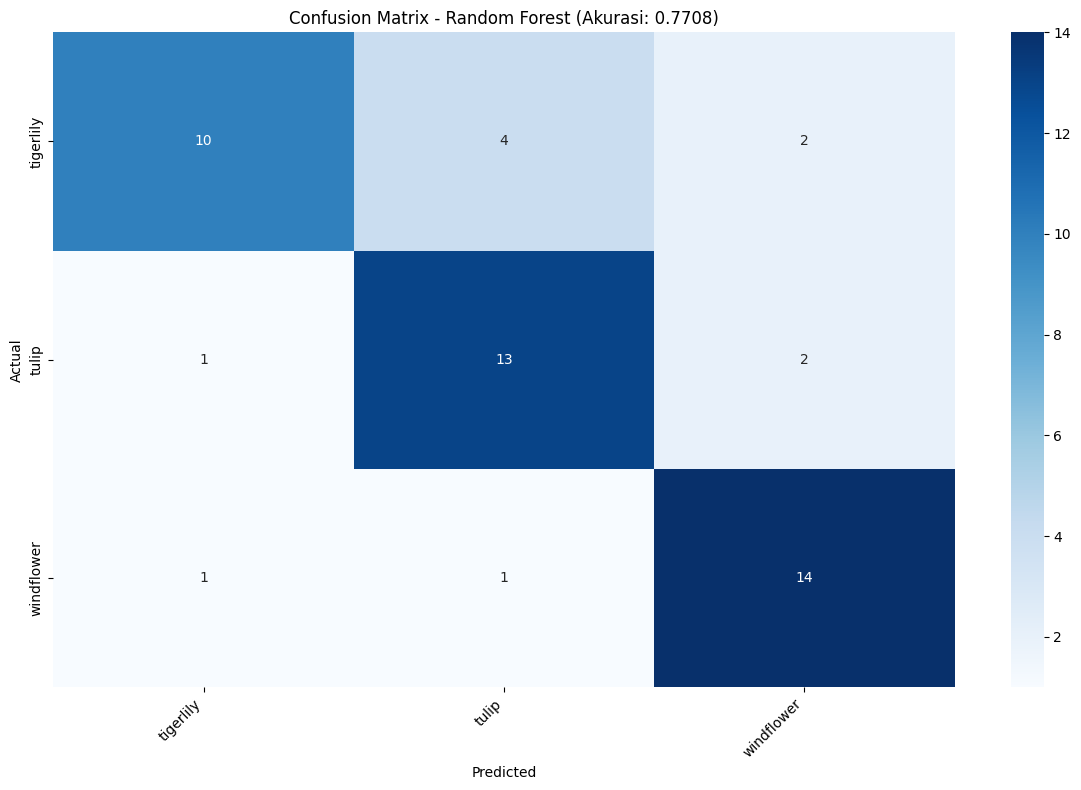

In [7]:
# Confusion Matrix
plt.figure(figsize=(12,8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.title(f'Confusion Matrix - Random Forest (Akurasi: {accuracy:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Feature importance

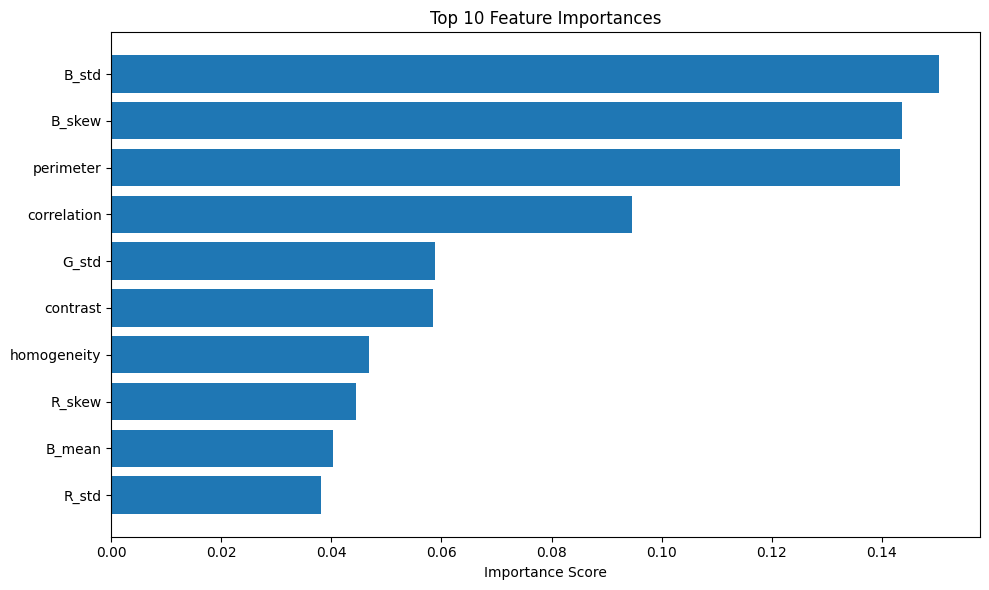

In [8]:
# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10,6))
plt.title('Top 10 Feature Importances')
plt.barh(range(10), importances[indices], align='center')
plt.yticks(range(10), [X.columns[i] for i in indices])
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()